<a href="https://colab.research.google.com/github/WistonTravieso/DS-Exploratory_Data_Analysis/blob/main/Copia_de_exploring_linear_regression_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Regresión Lineal en Python

A continuación veremos cómo podemos implementar este modelo en Python. Para ello, utilizaremos la librería `scikit-learn`.

### Regresión lineal simple

Para ejemplificar la implementación de un modelo de regresión lineal simple utilizaremos un conjunto de datos con pocas instancias y que ya ha sido previamente tratado con un EDA completo.

#### Paso 1. Lectura del conjunto de datos procesado

In [3]:
import pandas as pd

train_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_salary_train.csv")
test_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_salary_test.csv")

train_data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,2.0,43525.0
3,2.2,39891.0
4,2.9,56642.0


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  24 non-null     float64
 1   Salary           24 non-null     float64
dtypes: float64(2)
memory usage: 516.0 bytes


Como en este notebook no se ha mostrado el proceso de análisis exploratorio, a continuación y utilizando un diagrama de puntos se visualizará la relación entre la variable predictora y la objetivo (esto se ve en el análisis univariante):

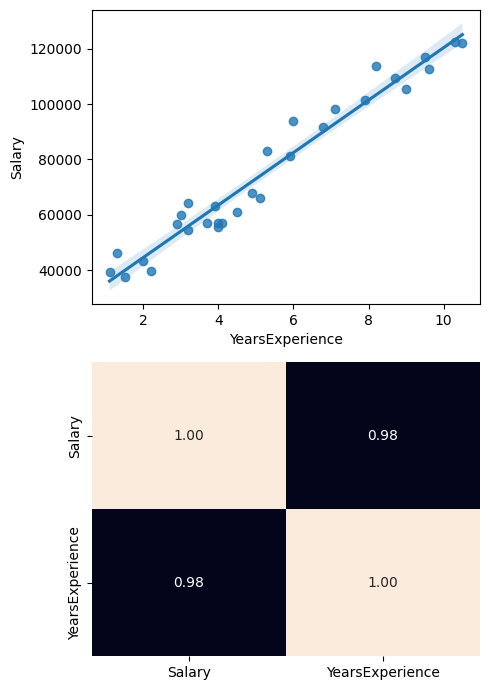

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(2, 1, figsize = (5, 7))
total_data = pd.concat([train_data, test_data])

sns.regplot(ax = axis[0], data = total_data, x = "YearsExperience", y = "Salary")
sns.heatmap(total_data[["Salary", "YearsExperience"]].corr(), annot = True, fmt = ".2f", ax = axis[1], cbar = False)

plt.tight_layout()

plt.show()

Existe una clara relación lineal entre la variable predictora y la objetivo, así que puede ser fácilmente modelizable por este tipo de modelos. Si la correlación fuera inferior, el modelo no tendría una buena precisión.

El conjunto train lo utilizaremos para entrenar el modelo, mientras que con el test lo evaluaremos para medir su grado de efectividad. Dividiremos también las predictoras de las características.

Además, al haber únicamente una variable predictora, no es necesario aplicar una normalización. En el caso de que hubiera varias sí que habría que aplicarla.

In [ ]:
X_train = train_data.drop(["Salary"], axis = 1)
y_train = train_data["Salary"]
X_test = test_data.drop(["Salary"], axis = 1)
y_test = test_data["Salary"]

#### Paso 2: Inicialización y entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Después del proceso de entrenamiento podemos conocer los parámetros (variables $a$ y $b$) que ha ajustado el modelo:

In [ ]:
print(f"Intercepto (a): {model.intercept_}")
print(f"Coeficientes (b): {model.coef_}")

Intercepto (a): 26354.43069701219
Coeficientes (b): [9277.78307971]


In [ ]:
y_ejm = 26354 + (9277)*(10)
y_ejm

119124

In [ ]:
26354 + (9277)*(5)


72739

En este caso hay solo un coeficiente ya que la regresión lineal es simple.

#### Paso 3: Predicción del modelo

In [ ]:
26354 + (9277)*(1.5)


40269.5

In [ ]:
X_test

,YearsExperience
0,1.5
1,3.0
2,4.5
3,6.8
4,8.2
5,10.3


In [ ]:
y_pred = model.predict(X_test)
y_pred

array([ 40271.10531658,  54187.77993614,  68104.45455571,  89443.35563904,
       102432.25195063, 121915.59641802])

In [ ]:
26354 + (9277)*(3)


54185

Para comparar el valor predicho del original, podemos fácilmente realizar un plot comprativo como el siguiente:

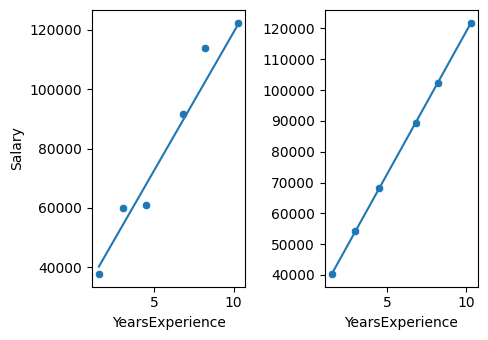

In [ ]:
fig, axis = plt.subplots(1, 2, figsize = (5, 3.5))
total_data = pd.concat([train_data, test_data])

# Utilizamos los parámetros ajustados en el entrenamiento para dibujar la línea de regresión en los plots
regression_equation = lambda x: 26354.43069701219 + 9277.78307971 * x

sns.scatterplot(ax = axis[0], data = test_data, x = "YearsExperience", y = "Salary")
sns.lineplot(ax = axis[0], x = test_data["YearsExperience"], y = regression_equation(test_data["YearsExperience"]))
sns.scatterplot(ax = axis[1], x = test_data["YearsExperience"], y = y_pred)
sns.lineplot(ax = axis[1], x = test_data["YearsExperience"], y = regression_equation(test_data["YearsExperience"])).set(ylabel = None)

plt.tight_layout()

plt.show()

Como vemos, el test predicho por el modelo siempre se ajustará a la ecuación de regresión, ya que es la que ha aprendido el modelo. La figura de la izquierda representa los valores reales mientras que los de la derecha, los predichos. Vemos que algunos valores predichos coinciden con los reales y que los que no tienen una diferencia notable. Veremos a continuación el valor de la métrica para conocer más acerca del rendimiento del algoritmo.

Para calcular la efectividad del modelo utilizaremos el **error cuadrático medio** (*MSE*) y el **coeficiente de determinación** ($R^2$), unas de las métricas más populares:

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 37649779.451336615
Coeficiente de determinación: 0.959714925174946


In [ ]:
import math
RMSE = math.sqrt(mean_squared_error(y_test, y_pred))
RMSE

6135.941610815459

Cuanto menor sea el valor del RMSE, mejor será el modelo. Un modelo perfecto (un modelo hipotético que siempre pueda predecir el valor esperado exacto) tendría un valor para esta métrica de 0. Observamos que hay un descuadre de 37 millones, por lo que podríamos entender que es muy malo. Si nos apoyamos en el valor del $R^2$, observamos que es de un 95%, un valor muy alto, luego el 95% de los datos están explicados por el modelo, por lo que es satisfactorio.

#### Paso 4: Optimización de resultados

Este tipo de modelos no se pueden optimizar, debido a la ausencia de hiperparámetros.

### Regresión lineal múltiple

Para ejemplificar la implementación de un modelo de regresión múltiple simple utilizaremos un conjunto de datos con pocas instancias y que ya ha sido previamente tratado con un EDA completo.

#### Paso 1. Lectura del conjunto de datos procesado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_weight-height_train.csv")
test_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/clean_weight-height_test.csv")

train_data.head()

,Gender,Height,Weight
0,-1.0,-0.575639,151.275533
1,-1.0,-0.992843,123.965162
2,-1.0,-0.925964,124.765438
3,-1.0,-1.478210,119.195698
4,1.0,-1.598649,146.956646


Para este problema, queremos calcular el peso (`weight`) en función de la altura (`height`) y del género (`gender`) de la persona. Por lo tanto, el peso será la variable dependiente (variable objetivo) y la altura y el género, las variables independientes (variables predictoras). Al tratarse de una predicción numérica continua, hemos de resolver esto con un modelo de regresión logística múltiple.

Como en este notebook no se ha mostrado el proceso de análisis exploratorio, a continuación y utilizando un diagrama de puntos se visualizará la relación entre la variable predictora y las variables objetivo (esto se ve en el análisis univariante):

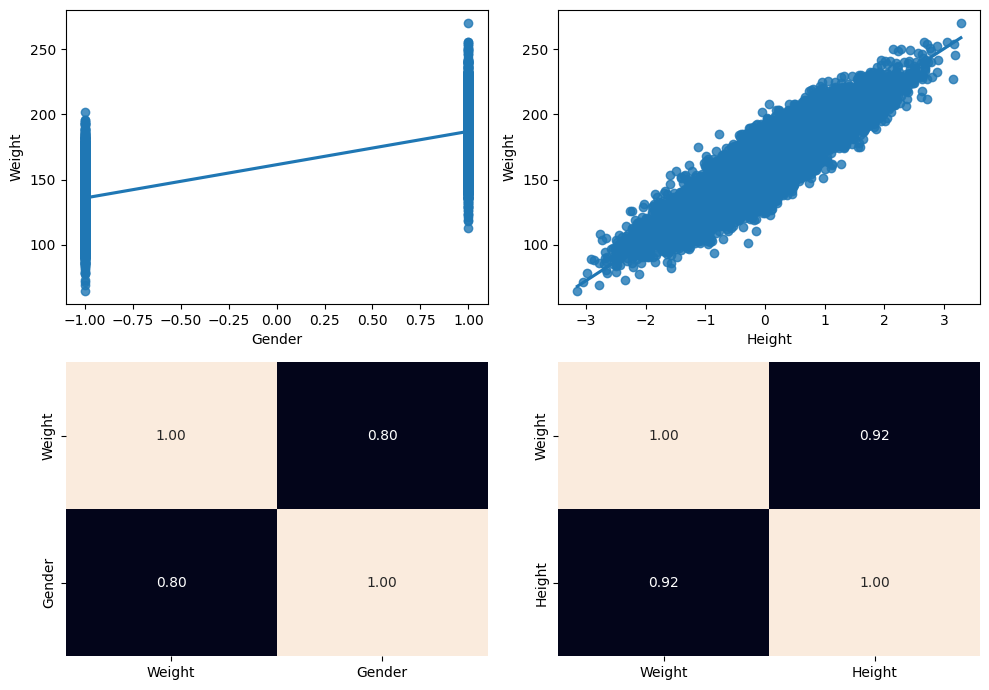

In [ ]:
fig, axis = plt.subplots(2, 2, figsize = (10, 7))
total_data = pd.concat([train_data, test_data])

sns.regplot(ax = axis[0, 0], data = total_data, x = "Gender", y = "Weight")
sns.heatmap(total_data[["Weight", "Gender"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "Height", y = "Weight")
sns.heatmap(total_data[["Weight", "Height"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

plt.tight_layout()

plt.show()

In [ ]:
total_data[["Height","Gender"]].corr()

,Height,Gender
Height,1.000000,0.691072
Gender,0.691072,1.000000


Existe una clara relación lineal entre la variable predictora y las objetivo, así que puede ser fácilmente modelizable por este tipo de modelos. Si la correlación fuera inferior, el modelo no tendría una buena precisión.

In [ ]:
X_train = train_data.drop(["Weight"], axis = 1)
y_train = train_data["Weight"]
X_test = test_data.drop(["Weight"], axis = 1)
y_test = test_data["Weight"]

#### Paso 2: Inicialización y entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LinearRegression

model_m = LinearRegression()
model_m.fit(X_train, y_train)

LinearRegression()

Después del proceso de entrenamiento podemos conocer los parámetros (variables $a$ y $b_1, b_2$) que ha ajustado el modelo:

In [ ]:
print(f"Intercepto (a): {model_m.intercept_}")
print(f"Coeficientes (b1, b2): {model_m.coef_}")

Intercepto (a): 161.48606316160345
Coeficientes (b1, b2): [ 9.65020608 22.88377295]


#### Paso 3: Predicción del modelo

In [ ]:
y_pred = model_m.predict(X_test)
y_pred

array([105.17851056, 188.29501423, 137.05824216, ..., 112.17172027,
       130.89667195, 137.46475059])

In [ ]:
X_test.loc[0]

,0
Gender,-1.000000
Height,-2.038883


In [ ]:
161 + (9.6)*(-1.000000) + (22.8)* (-2.038883)

104.91346760000002

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 98.21235363443171
Coeficiente de determinación: 0.9075866115171992


In [ ]:
import math
math.sqrt(mean_squared_error(y_test, y_pred))

9.910214610916945

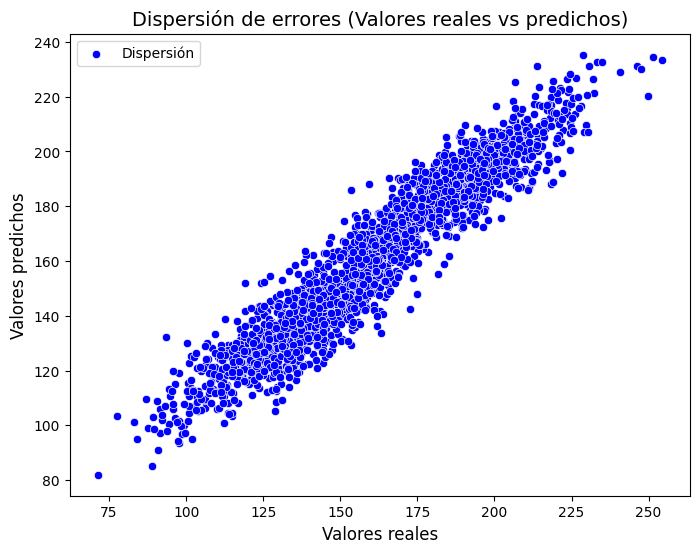

In [ ]:
## Dispesión de errores
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Dispersión')
plt.xlabel('Valores reales', fontsize=12)
plt.ylabel('Valores predichos', fontsize=12)
plt.title('Dispersión de errores (Valores reales vs predichos)', fontsize=14);



Si nos apoyamos en el valor del $R^2$, observamos que es de un 90%, un valor muy alto, luego el 90% de los datos están explicados por el modelo, por lo que es satisfactorio.

#### Paso 4: Optimización de resultados

Este tipo de modelos no se pueden optimizar, debido a la ausencia de hiperparámetros.

### Paso 5: Modelos Lineales Regularizados

* **Lasso**
* **Ridge**


#### Modelo Lasso (L1)

In [ ]:
## Importar librerias
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [ ]:
## Busqueda de hiper-parámetros
lasso_m = {'alpha': np.logspace(-5, 5, 100)}

lasso_grid = GridSearchCV(Lasso(),
        lasso_m,
        n_jobs = -1,
        scoring= 'neg_root_mean_squared_error',
        cv= 5
       )

lasso_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-05, 1.26185688e-05, 1.59228279e-05, 2.00923300e-05,
       2.53536449e-05, 3.19926714e-05, 4.03701726e-05, 5.09413801e-05,
       6.42807312e-05, 8.11130831e-05, 1.02353102e-04, 1.29154967e-04,
       1.62975083e-04, 2.05651231e-04, 2.59502421e-04, 3.27454916e-04,
       4.13201240e-04, 5.21400829e-04, 6.57933...
       4.75081016e+02, 5.99484250e+02, 7.56463328e+02, 9.54548457e+02,
       1.20450354e+03, 1.51991108e+03, 1.91791026e+03, 2.42012826e+03,
       3.05385551e+03, 3.85352859e+03, 4.86260158e+03, 6.13590727e+03,
       7.74263683e+03, 9.77009957e+03, 1.23284674e+04, 1.55567614e+04,
       1.96304065e+04, 2.47707636e+04, 3.12571585e+04, 3.94420606e+04,
       4.97702356e+04, 6.28029144e+04, 7.92482898e+04, 1.00000000e+05])},
             scoring='neg_root_mean_squared_error')

In [ ]:
### Mejores parámetros
lasso_grid.best_params_

{'alpha': np.float64(0.00032745491628777284)}

In [ ]:
## Mejor modelo
best_lasso_grid = Lasso(alpha = 0.00032745491628777284)
best_lasso_grid.fit(X_train, y_train)

Lasso(alpha=0.00032745491628777284)

In [ ]:
## Presicción lasso
y_pred_lasso_grid = best_lasso_grid.predict(X_test)
y_pred_lasso_grid

array([105.17954748, 188.29520062, 137.05796688, ..., 112.17246934,
       130.89665028, 137.46445857])

In [ ]:
### Raiz cuadrada del error
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso_grid)}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_lasso_grid))}')
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_lasso_grid)}")

MSE: 98.21263057995755
RMSE:9.910228583638096
Coeficiente de determinación: 0.9075863509239691


In [ ]:
## Busqueda de hiper-parámetros empleando Random
lasso_m2 = {'alpha': np.linspace(0,50,500)}

lasso_ran = RandomizedSearchCV(Lasso(),
        lasso_m2,
        n_iter = 100,
        scoring= 'neg_root_mean_squared_error',
        cv = 5
       )

lasso_ran.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=100,
                   param_distributions={'alpha': array([ 0.        ,  0.1002004 ,  0.2004008 ,  0.3006012 ,  0.4008016 ,
        0.501002  ,  0.6012024 ,  0.70140281,  0.80160321,  0.90180361,
        1.00200401,  1.10220441,  1.20240481,  1.30260521,  1.40280561,
        1.50300601,  1.60320641,  1.70340681,  1.80360721,  1.90380762,
        2.00400802,  2.10420842,  2.20440882,  2.30460922,  2.40480962,
        2...
       47.09418838, 47.19438878, 47.29458918, 47.39478958, 47.49498998,
       47.59519038, 47.69539078, 47.79559118, 47.89579158, 47.99599198,
       48.09619238, 48.19639279, 48.29659319, 48.39679359, 48.49699399,
       48.59719439, 48.69739479, 48.79759519, 48.89779559, 48.99799599,
       49.09819639, 49.19839679, 49.29859719, 49.3987976 , 49.498998  ,
       49.5991984 , 49.6993988 , 49.7995992 , 49.8997996 , 50.        ])},
                   scoring='neg_root_mean_squared_error')

In [ ]:
### Mejores parámetros
lasso_ran.best_params_

{'alpha': np.float64(0.30060120240480964)}

In [ ]:
## Mejor modelo
best_lasso = Lasso(alpha = 0.30060120240480964)
best_lasso.fit(X_train, y_train)

Lasso(alpha=0.30060120240480964)

In [ ]:
## Presicción lasso
y_pred_lasso = best_lasso.predict(X_test)
y_pred_lasso

array([105.72075753, 187.98599203, 137.35161152, ..., 112.65937288,
       131.23814324, 137.75494643])

In [ ]:
### Raiz cuadrada del error
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso)}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_lasso))}')
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_lasso)}")

MSE: 98.77095289083317
RMSE:9.938357655610567
Coeficiente de determinación: 0.907060994849054


In [ ]:
print(f"Intercepto (a) grid: {best_lasso_grid.intercept_}")
print(f"Coeficientes (b1, b2) grid: {best_lasso_grid.coef_}")

print("----------------------------------------------------------------------")

print(f"Intercepto (a) random: {best_lasso.intercept_}")
print(f"Coeficientes (b1, b2) random: {best_lasso.coef_}")

Intercepto (a) grid: 161.48606771877024
Coeficientes (b1, b2) grid: [ 9.65109419 22.88283103]
----------------------------------------------------------------------
Intercepto (a) random: 161.48753119844747
Coeficientes (b1, b2) random: [ 9.47367016 22.70512468]


#### Modelo Ridge (L2)

In [ ]:
## Busqueda de hiper-parámetros
#ridge_m = {'alpha': np.linspace(0,10,200)}
ridge_m = {'alpha': np.logspace(-5, 5, 200)}

ridge_grid = GridSearchCV(Ridge(),
        ridge_m,
        n_jobs = -1,
        scoring= 'neg_root_mean_squared_error',
        cv= 5
       )

ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-05, 1.12266777e-05, 1.26038293e-05, 1.41499130e-05,
       1.58856513e-05, 1.78343088e-05, 2.00220037e-05, 2.24780583e-05,
       2.52353917e-05, 2.83309610e-05, 3.18062569e-05, 3.57078596e-05,
       4.00880633e-05, 4.50055768e-05, 5.05263107e-05, 5.67242607e-05,
       6.36824994e-05, 7.14942899e-05, 8.02643...
       6.98587975e+03, 7.84282206e+03, 8.80488358e+03, 9.88495905e+03,
       1.10975250e+04, 1.24588336e+04, 1.39871310e+04, 1.57029012e+04,
       1.76291412e+04, 1.97916687e+04, 2.22194686e+04, 2.49450814e+04,
       2.80050389e+04, 3.14403547e+04, 3.52970730e+04, 3.96268864e+04,
       4.44878283e+04, 4.99450512e+04, 5.60716994e+04, 6.29498899e+04,
       7.06718127e+04, 7.93409667e+04, 8.90735464e+04, 1.00000000e+05])},
             scoring='neg_root_mean_squared_error')

In [ ]:
### Mejores parámetros
ridge_grid.best_params_

{'alpha': np.float64(1e-05)}

In [ ]:
## Mejor modelo
best_ridge_grid = Ridge(**ridge_grid.best_params_)
best_ridge_grid.fit(X_train, y_train)

Ridge(alpha=np.float64(1e-05))

In [ ]:
## Presicción ridge
y_pred_ridge_grid = best_ridge_grid.predict(X_test)
y_pred_ridge_grid

array([105.17851063, 188.29501422, 137.05824217, ..., 112.17172032,
       130.89667197, 137.4647506 ])

In [ ]:
### Raiz cuadrada del error
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge_grid)}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_ridge_grid))}')
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_ridge_grid)}")

MSE: 98.21235367112196
RMSE:9.910214612768078
Coeficiente de determinación: 0.9075866114826754


In [ ]:
## Busqueda de hiper-parámetros empleando Random
ridge_m2 = {'alpha': np.linspace(0,50,600)}

ridge_ran = RandomizedSearchCV(Ridge(),
        ridge_m2,
        n_iter = 100,
        scoring= 'neg_root_mean_squared_error',
        cv = 5
       )

ridge_ran.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=100,
                   param_distributions={'alpha': array([ 0.        ,  0.08347245,  0.16694491,  0.25041736,  0.33388982,
        0.41736227,  0.50083472,  0.58430718,  0.66777963,  0.75125209,
        0.83472454,  0.91819699,  1.00166945,  1.0851419 ,  1.16861436,
        1.25208681,  1.33555927,  1.41903172,  1.50250417,  1.58597663,
        1.66944908,  1.75292154,  1.83639399,  1.91986644,  2.0033...
       47.57929883, 47.66277129, 47.74624374, 47.82971619, 47.91318865,
       47.9966611 , 48.08013356, 48.16360601, 48.24707846, 48.33055092,
       48.41402337, 48.49749583, 48.58096828, 48.66444073, 48.74791319,
       48.83138564, 48.9148581 , 48.99833055, 49.08180301, 49.16527546,
       49.24874791, 49.33222037, 49.41569282, 49.49916528, 49.58263773,
       49.66611018, 49.74958264, 49.83305509, 49.91652755, 50.        ])},
                   scoring='neg_root_mean_squared_error')

In [2]:
### Mejores parámetros
ridge_ran.best_params_

NameError: name 'ridge_ran' is not defined

In [ ]:
## Mejor modelo
best_ridge = Ridge(**ridge_ran.best_params_)
best_ridge.fit(X_train, y_train)

Ridge(alpha=np.float64(0.41736227045075125))

In [ ]:
## Presicción ridge
y_pred_ridge = best_ridge.predict(X_test)
y_pred_ridge

array([105.18120858, 188.29442535, 137.0586812 , ..., 112.17392275,
       130.89754759, 137.46516082])

In [ ]:
### Raiz cuadrada del error
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test, y_pred_ridge))}')
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_ridge)}")

MSE: 98.21388649943708
RMSE:9.910291948244364
Coeficiente de determinación: 0.9075851691604693


In [ ]:
print(f"Intercepto (a) grid: {best_ridge_grid.intercept_}")
print(f"Coeficientes (b1, b2) grid: {best_ridge_grid.coef_}")

print("----------------------------------------------------------------------")

print(f"Intercepto (a) random: {best_ridge.intercept_}")
print(f"Coeficientes (b1, b2) random: {best_ridge.coef_}")

Intercepto (a) grid: 161.48606316182966
Coeficientes (b1, b2) grid: [ 9.6502061  22.88377291]
----------------------------------------------------------------------
Intercepto (a) random: 161.48607260169442
Coeficientes (b1, b2) random: [ 9.65082362 22.88215142]


In [ ]:
Variacion = (0.9075848797597564-0.9075866115171992)/0.9075866115171992
Variacion*100

-0.00019080905566522477

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.032e+05, tolerance: 8.181e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

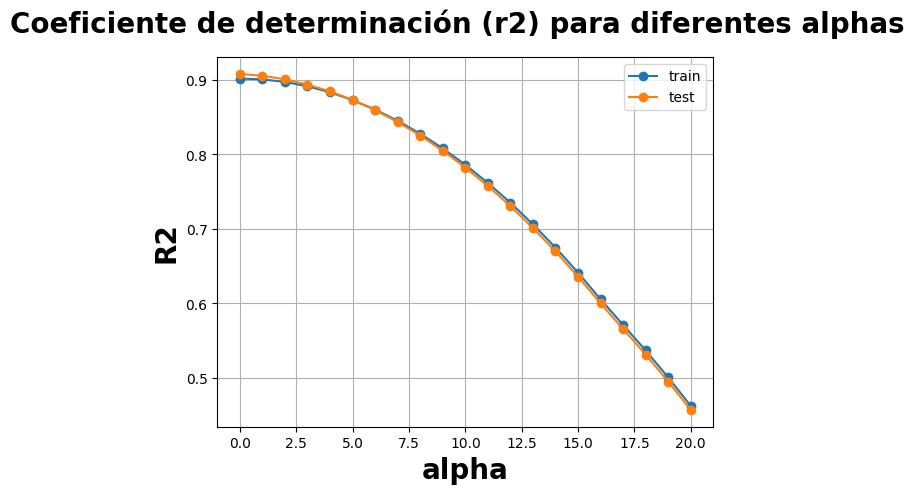

In [ ]:
# Definimos la lista de valores alpha
alpha = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

lista_r2_train = []
lista_r2_test = []

for item in alpha:

    model = Lasso(alpha = item)

    model.fit(X_train,y_train)

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)

    # Agregar la información a las listas
    lista_r2_train.append(train_r2)
    lista_r2_test.append(test_r2)

plt.suptitle('Coeficiente de determinación (r2) para diferentes alphas' , fontweight = 'black', fontsize=20)
plt.plot(alpha,lista_r2_train,'o-',label='train' )
plt.plot(alpha,lista_r2_test,'o-',label='test')
plt.grid(True)
plt.legend()
plt.xlabel('alpha',fontsize=20,fontweight = 'black')
plt.ylabel('R2',fontsize=20,fontweight = 'black');

# Bayes Search

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
1e-6

1e-06

In [ ]:
1e+3

1000.0

In [ ]:
### Emplear búsqueda con un modelo Bayes
from skopt import BayesSearchCV

## alpha con escala logarítmica

ridge_search = {
    'alpha': (1e-6, 1e+3, 'log-uniform') }

### Definición de Bayes search
bayes_ridge = BayesSearchCV(
    estimator=Ridge(),
    search_spaces=ridge_search,
    n_iter=70,
    cv=5,
    n_jobs=-1
)


bayes_ridge.fit(X_train,y_train)

BayesSearchCV(cv=5, estimator=Ridge(), n_iter=70, n_jobs=-1,
              search_spaces={'alpha': (1e-06, 1000.0, 'log-uniform')})

In [ ]:
bayes_ridge

BayesSearchCV(cv=5, estimator=Ridge(), n_iter=70, n_jobs=-1,
              search_spaces={'alpha': (1e-06, 1000.0, 'log-uniform')})

In [ ]:
bayes_ridge.best_params_

OrderedDict([('alpha', 2.566896206762824)])

In [1]:
bayes_ridge.best_estimator_

NameError: name 'bayes_ridge' is not defined

In [ ]:
bayes_ridge.best_score_

np.float64(0.9012477938945993)